In [1]:
# Operations
import numpy as np
import pandas as pd
from numpy.linalg import inv
from numpy import random

# SciPy
import scipy 
from scipy import stats
from scipy.stats import binom, poisson, expon, norm, t, rv_discrete

# Statistics
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats import proportion as ssp
from scipy.stats import f
from scipy.stats import chi2
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep

# Plots
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

# Case Study: Exploratory Data Analysis on Used Cars Dataset

## Tasks

In [2]:
df = pd.read_csv('used_cars_data_csv.csv')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [5]:
df.shape

(7253, 14)

In [6]:
df.columns

Index(['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_Price', 'Price'],
      dtype='object')

In [7]:
df.dtypes

S.No.                  int64
Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
New_Price             object
Price                float64
dtype: object

In [8]:
brands = [
    "Maruti",
    "Hyundai",
    "Honda",
    "Toyota",
    "Mercedes-Benz",
    "Volkswagen",
    "Ford",
    "Mahindra",
    "BMW",
    "Audi",
    "Tata",
    "Skoda",
    "Renault",
    "Nissan",
    "Jaguar",
    "Fiat",
    "Mitsubishi",
    "Mini",
    "Volvo",
    "Porsche",
    "Jeep",
    "Datsun",
    "Isuzu",
    "Force Motors",
    "Bentley",
    "Smart",
    "Ambassador",
    "Lamborghini",
    "Hindustan Motors",
    "Opel Corsa",
    "Land Rover"
]


brands_sorted = sorted(brands, key=len, reverse=True)

In [9]:
def extract_brand(name):
    for b in brands_sorted:
        if name.startswith(b):
            return b
    return None

df['brand_clean'] = df['Name'].apply(extract_brand)

In [10]:
df.isnull().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
brand_clean           158
dtype: int64

In [11]:
df['price_imputed'] = df['Price'].isna()
df['Price'] = df['Price'].fillna(df['Price'].median())

In [12]:
df['Seats'] = df['Seats'].fillna(df['Seats'].mode())

In [13]:
df['Mileage_num'] = df['Mileage'].str.split(expand = True)[0].astype(float)
df['Mileage_num'] = df['Mileage_num'].fillna(df['Mileage_num'].median())
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,brand_clean,price_imputed,Mileage_num
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti,False,26.60
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai,False,19.67
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,False,18.20
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti,False,20.77
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi,False,15.20


In [14]:
df['Engine_cc'] = df['Engine'].str.split(expand = True)[0].astype(float)
df['Engine_cc'] = df['Engine_cc'].fillna(df['Engine_cc'].mode()[0])
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,brand_clean,price_imputed,Mileage_num,Engine_cc
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti,False,26.60,998.0
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai,False,19.67,1582.0
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,False,18.20,1199.0
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti,False,20.77,1248.0
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi,False,15.20,1968.0


In [15]:
df['Power_bhp'] = df['Power'].str.extract(r'(\d+\.?\d*)').astype(float)

df['Power_bhp'] = (
    df.groupby('brand_clean')['Power_bhp']
    .transform(lambda x: x.fillna(x.median()))
)


df['Power_bhp']=df['Power_bhp'].fillna(df['Power_bhp'].median())
df.head()

C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,brand_clean,price_imputed,Mileage_num,Engine_cc,Power_bhp
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti,False,26.60,998.0,58.16
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai,False,19.67,1582.0,126.20
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,False,18.20,1199.0,88.70
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti,False,20.77,1248.0,88.76
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi,False,15.20,1968.0,140.80


In [16]:
df['Seats'] = df['Seats'].fillna(df['Seats'].mode()[0])
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,brand_clean,price_imputed,Mileage_num,Engine_cc,Power_bhp
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti,False,26.60,998.0,58.16
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai,False,19.67,1582.0,126.20
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,False,18.20,1199.0,88.70
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti,False,20.77,1248.0,88.76
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi,False,15.20,1968.0,140.80


In [17]:
df.isna().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                   0
New_Price            6247
Price                   0
brand_clean           158
price_imputed           0
Mileage_num             0
Engine_cc               0
Power_bhp               0
dtype: int64

In [18]:
df.describe()

,S.No.,Year,Kilometers_Driven,Seats,Price,Mileage_num,Engine_cc,Power_bhp
count,7253.000000,7253.000000,7.253000e+03,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000
mean,3626.000000,2013.365366,5.869906e+04,5.277678,8.826235,18.141586,1613.912450,112.495248
std,2093.905084,3.254421,8.442772e+04,0.809039,10.293313,4.561567,594.328359,52.966191
min,0.000000,1996.000000,1.710000e+02,0.000000,0.440000,0.000000,72.000000,34.200000
25%,1813.000000,2011.000000,3.400000e+04,5.000000,3.850000,15.170000,1197.000000,78.900000
50%,3626.000000,2014.000000,5.341600e+04,5.000000,5.640000,18.160000,1462.000000,94.000000
75%,5439.000000,2016.000000,7.300000e+04,5.000000,8.400000,21.100000,1968.000000,138.000000
max,7252.000000,2019.000000,6.500000e+06,10.000000,160.000000,33.540000,5998.000000,616.000000


In [19]:
df.duplicated().value_counts()

False    7253
Name: count, dtype: int64

## Descriptive Analysis

In [20]:
df.describe()

,S.No.,Year,Kilometers_Driven,Seats,Price,Mileage_num,Engine_cc,Power_bhp
count,7253.000000,7253.000000,7.253000e+03,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000
mean,3626.000000,2013.365366,5.869906e+04,5.277678,8.826235,18.141586,1613.912450,112.495248
std,2093.905084,3.254421,8.442772e+04,0.809039,10.293313,4.561567,594.328359,52.966191
min,0.000000,1996.000000,1.710000e+02,0.000000,0.440000,0.000000,72.000000,34.200000
25%,1813.000000,2011.000000,3.400000e+04,5.000000,3.850000,15.170000,1197.000000,78.900000
50%,3626.000000,2014.000000,5.341600e+04,5.000000,5.640000,18.160000,1462.000000,94.000000
75%,5439.000000,2016.000000,7.300000e+04,5.000000,8.400000,21.100000,1968.000000,138.000000
max,7252.000000,2019.000000,6.500000e+06,10.000000,160.000000,33.540000,5998.000000,616.000000


In [21]:
df['Fuel_Type'].value_counts()

Fuel_Type
Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: count, dtype: int64

In [22]:
df['Transmission'].value_counts()

Transmission
Manual       5204
Automatic    2049
Name: count, dtype: int64

In [23]:
df['Owner_Type'].value_counts()

Owner_Type
First             5952
Second            1152
Third              137
Fourth & Above      12
Name: count, dtype: int64

In [24]:
df['Location'].value_counts()

Location
Mumbai        949
Hyderabad     876
Coimbatore    772
Kochi         772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Ahmedabad     275
Name: count, dtype: int64

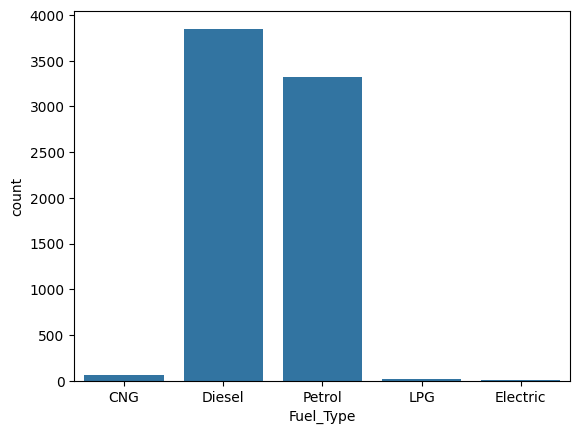

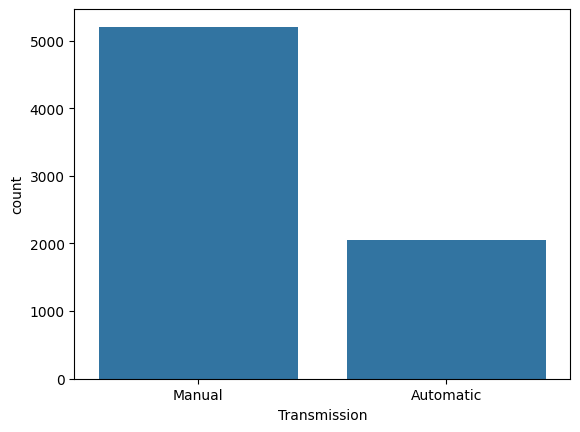

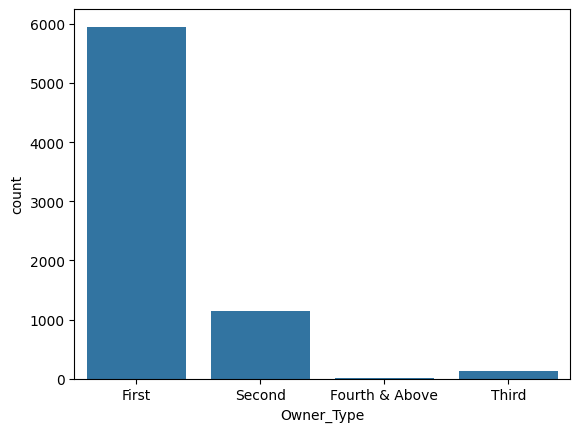

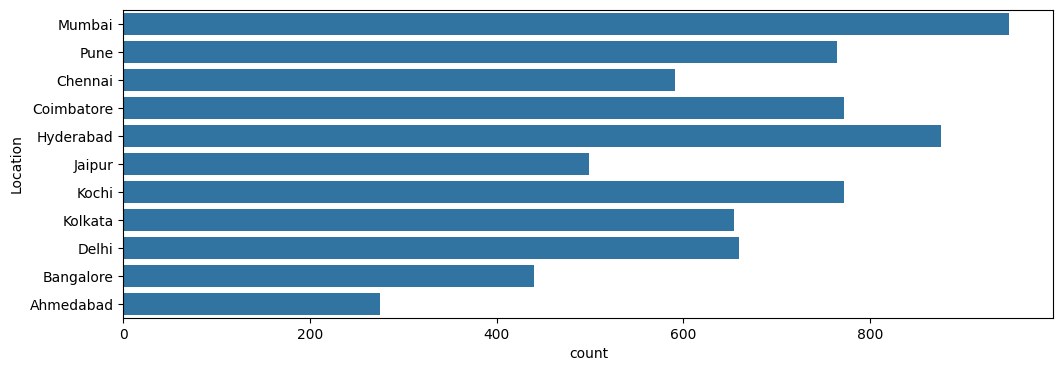

In [25]:
sns.countplot(data=df, x='Fuel_Type')
plt.show()

sns.countplot(data=df, x='Transmission')
plt.show()

sns.countplot(data=df, x='Owner_Type')
plt.show()

plt.figure(figsize=(12,4))
sns.countplot(data=df, y='Location')
plt.show()

## Visual Explorations

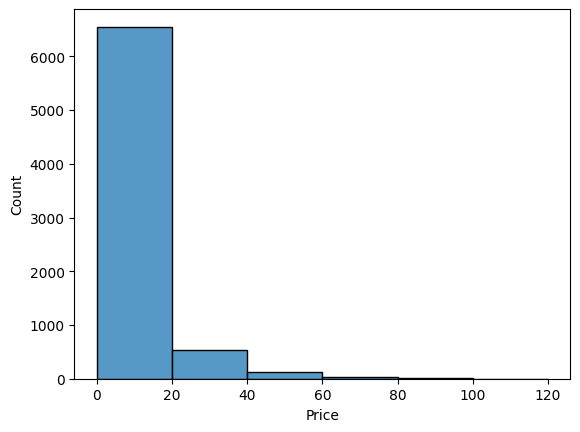

In [26]:
sns.histplot(x='Price', data=df, bins=[0,20,40,60,80,100,120])
plt.show()

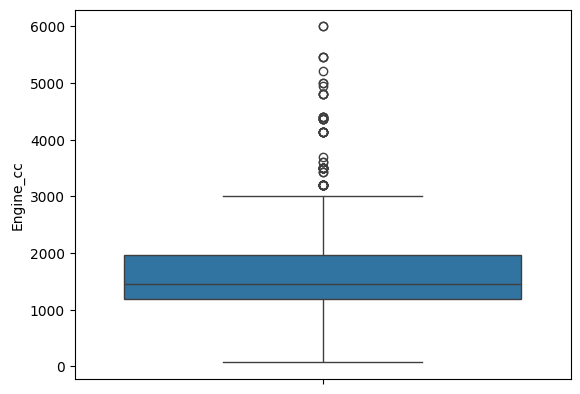

In [27]:
sns.boxplot(y='Engine_cc', data=df)
plt.show()

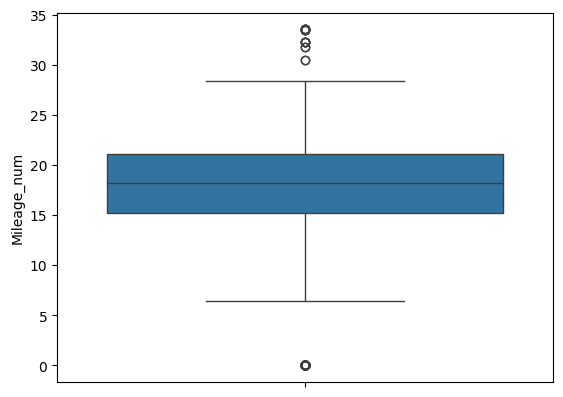

In [28]:
sns.boxplot(y='Mileage_num',data=df)
plt.show()

Fuel_Type
Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: count, dtype: int64


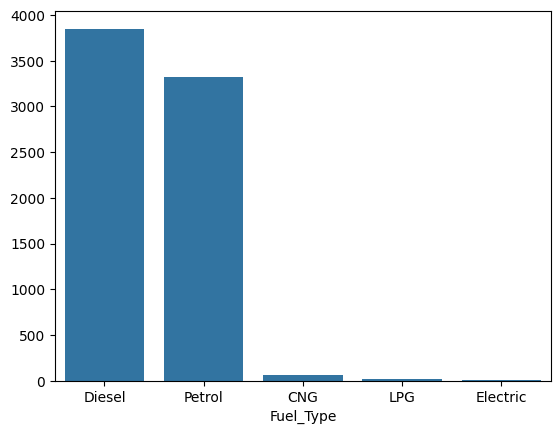

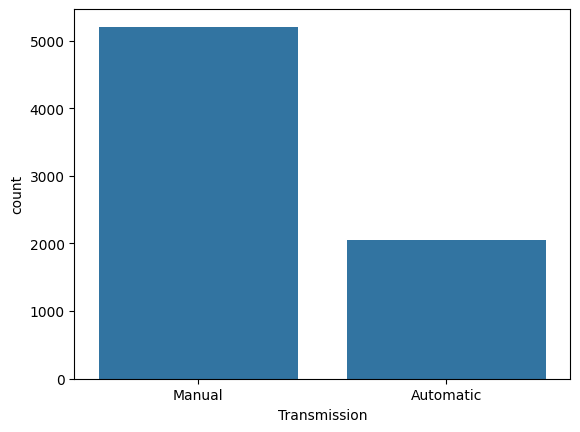

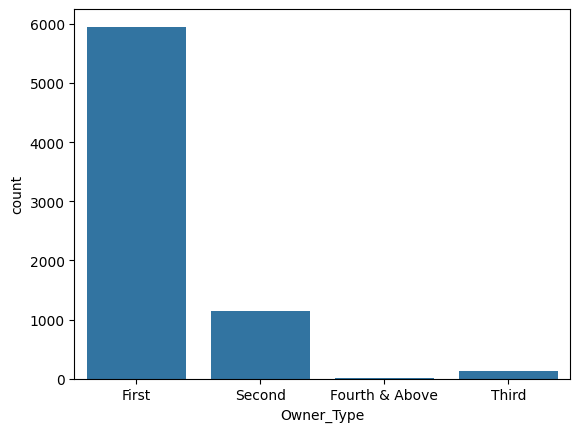

In [29]:
fc = df['Fuel_Type'].value_counts()
print(fc)
# using Barplot command
sns.barplot(x=fc.index, y=fc.values)
plt.show()

# using countplot command
sns.countplot(data=df, x='Transmission')
plt.show()

sns.countplot(data=df, x='Owner_Type')
plt.show()

plt.show()

In [30]:
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,brand_clean,price_imputed,Mileage_num,Engine_cc,Power_bhp
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti,False,26.60,998.0,58.16
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai,False,19.67,1582.0,126.20
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,False,18.20,1199.0,88.70
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti,False,20.77,1248.0,88.76
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi,False,15.20,1968.0,140.80


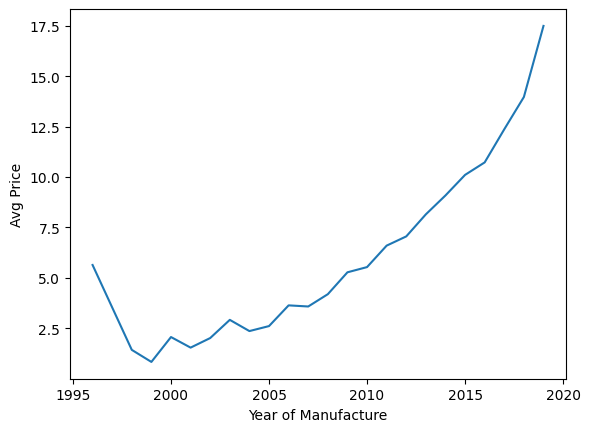

In [31]:
# andlyzing price trends over the years
sns.lineplot(data=df, x = 'Year', y = 'Price', errorbar = None)
plt.xlabel('Year of Manufacture')
plt.ylabel('Avg Price')
plt.show()

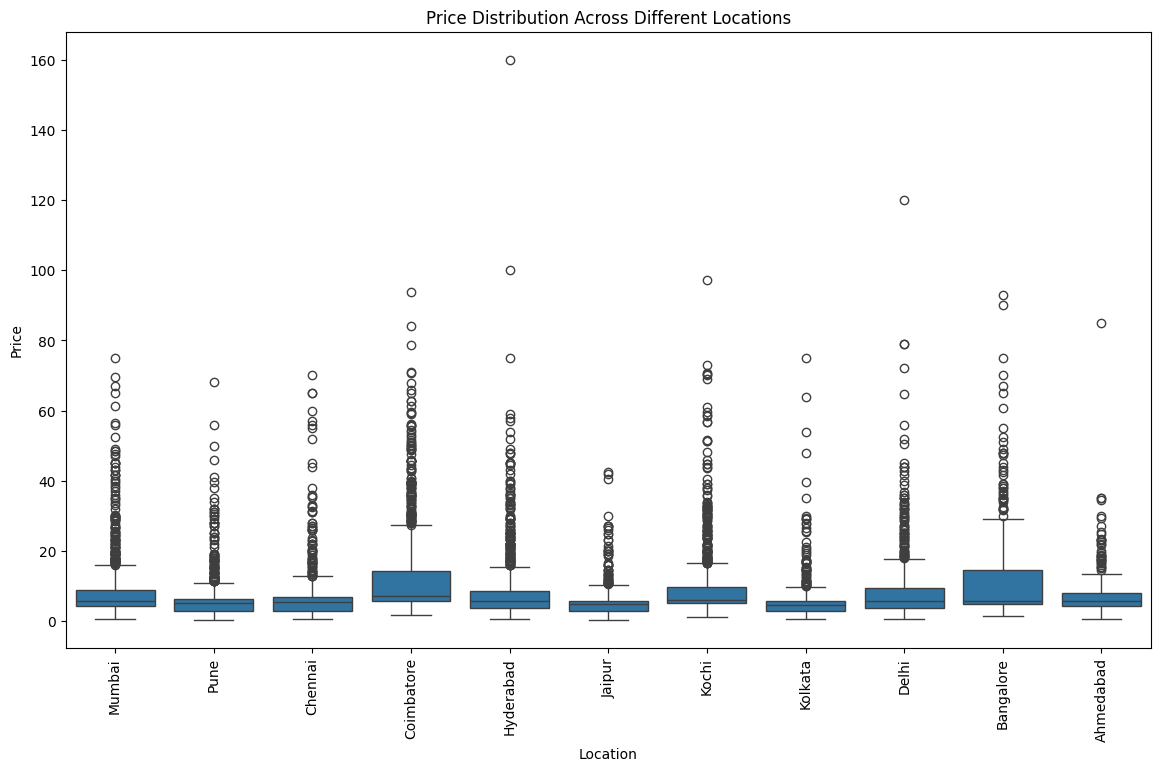

In [41]:
# Price Distributions across different Locations
plt.figure(figsize = (14,8))
sns.boxplot(x = 'Location', y = 'Price', data = df)
plt.title("Price Distribution Across Different Locations")
plt.xticks(rotation = 90)
plt.show()

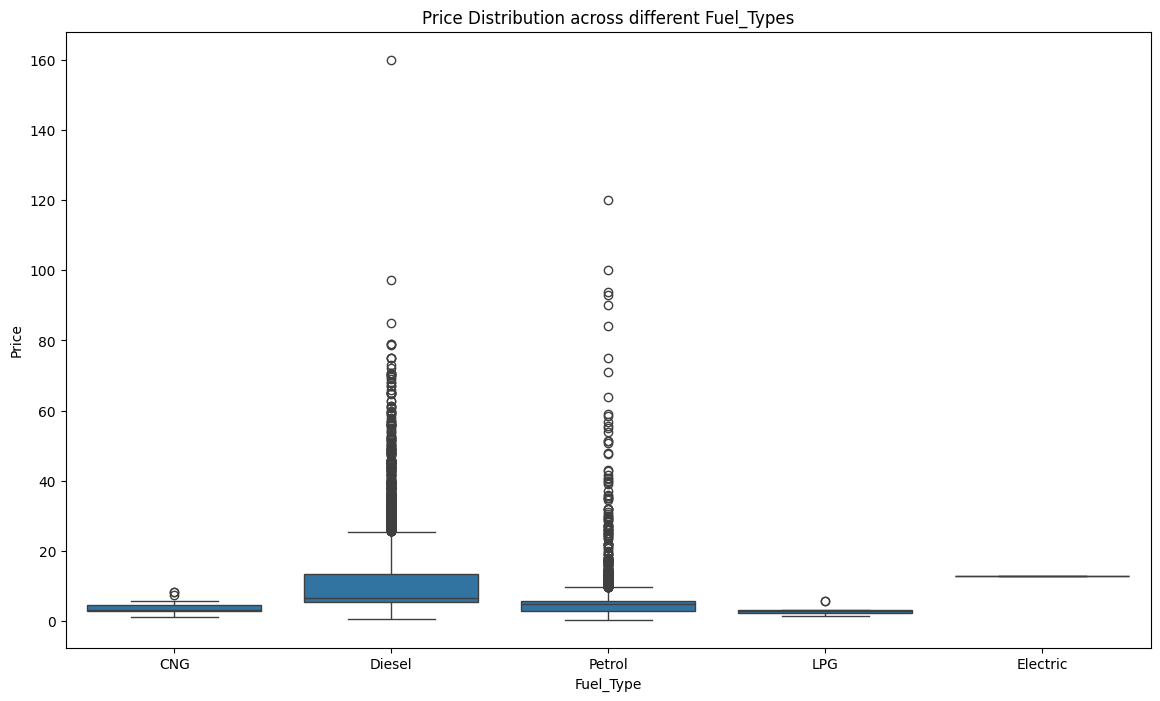

In [43]:
# Price Distribution across different fuel_types
plt.figure(figsize = (14,8))
sns.boxplot(data = df, x = 'Fuel_Type', y = 'Price')
plt.title('Price Distribution across different Fuel_Types')
plt.show()

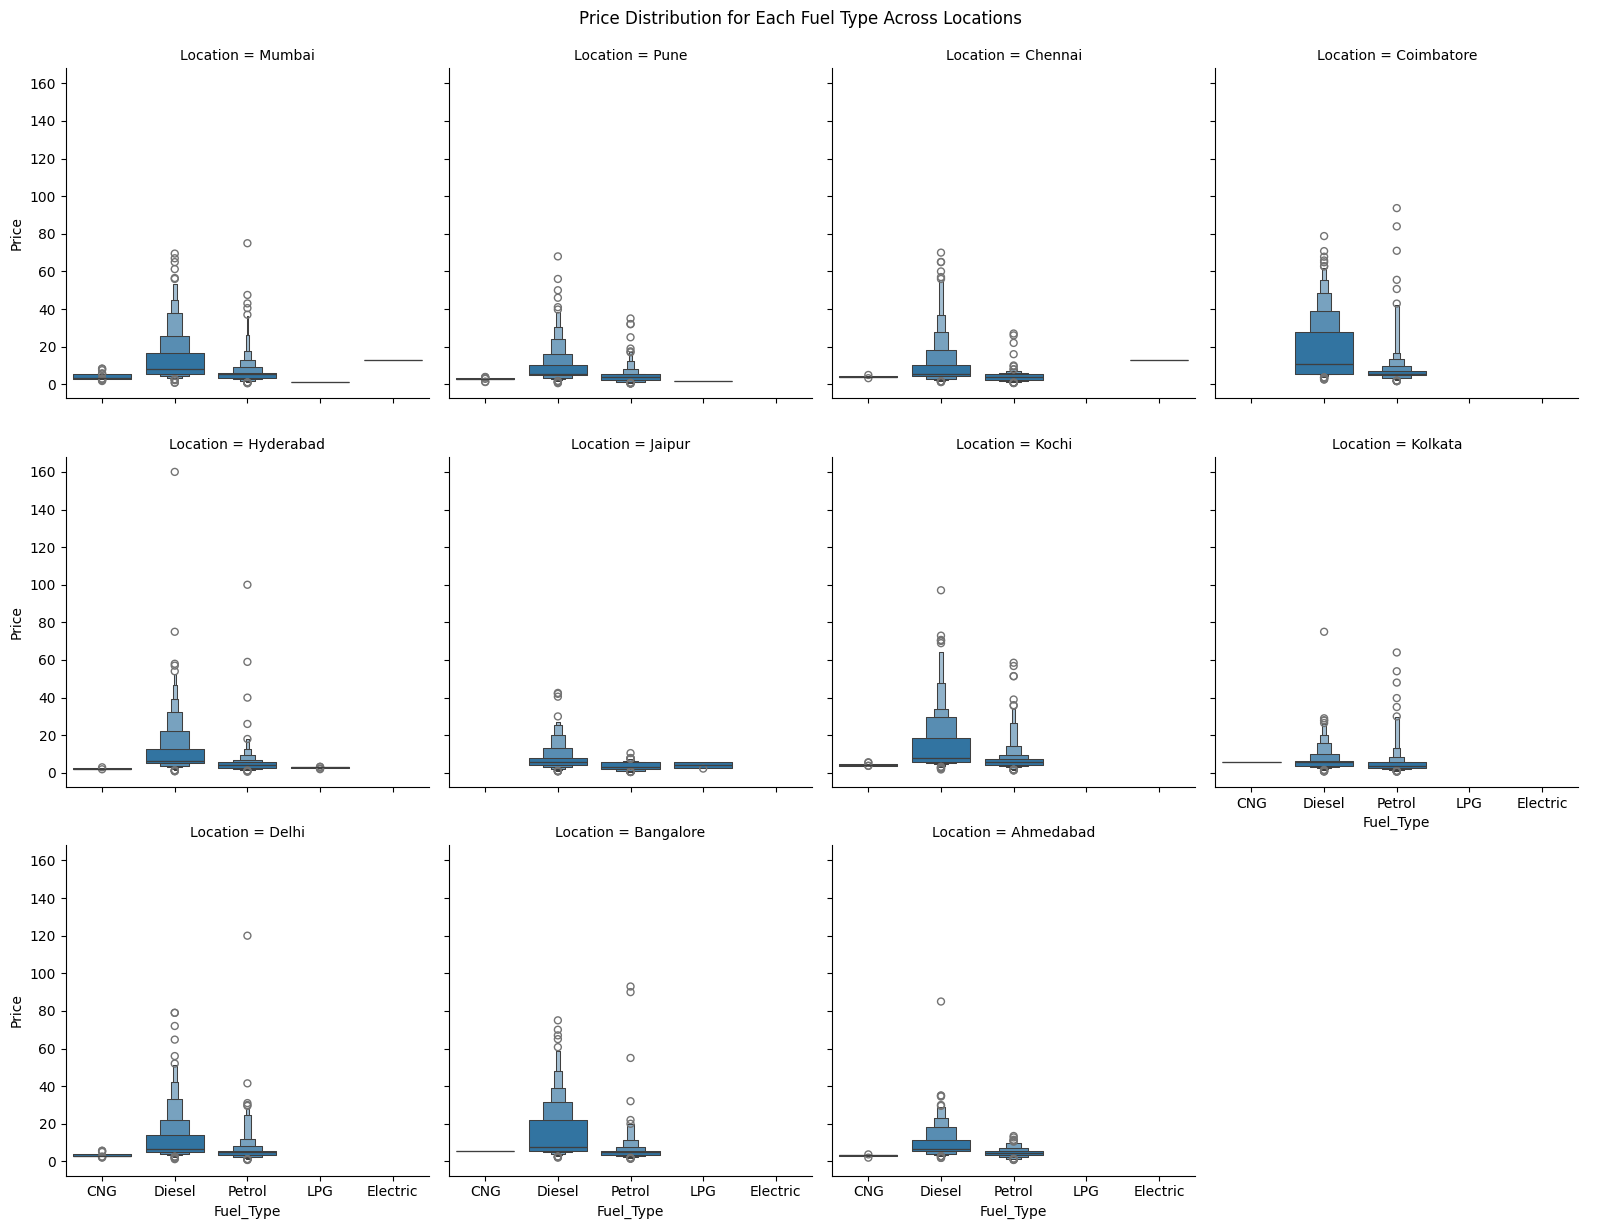

In [53]:
g = sns.catplot(
    data=df,
    x='Fuel_Type',
    y='Price',
    col='Location',
    kind='boxen',
    col_wrap=4,
    height=4
)
g.fig.suptitle("Price Distribution for Each Fuel Type Across Locations", y=1.02)
plt.show()

In [ ]:
# Create a flag for imputed values
df['price_imputed'] = df['Price'].isna()

In [ ]:
df['Price'] = df['Price'].fillna(df['Price'].median())

In [ ]:
df.head()

In [ ]:
mod1 = ols('Price ~ Transmission*Fuel_Type',df).fit()
tbl1 = sm.stats.anova_lm(mod1)
tbl1

In [ ]:
df['New_Price_num'] = (
    df['New_Price']
    .str.replace("Lakh", "", regex=False)
    .str.replace("Cr", "", regex=False)
    .str.strip()
)

# Multiply based on unit
df.loc[df['New_Price'].str.contains("Lakh", na=True), 'New_Price_num'] = (
    df.loc[df['New_Price'].str.contains("Lakh", na=True), 'New_Price_num'].astype(float) * 100000
)

df.loc[df['New_Price'].str.contains("Cr", na=True), 'New_Price_num'] = (
    df.loc[df['New_Price'].str.contains("Cr", na=True), 'New_Price_num'].astype(float) * 10000000
)


In [ ]:
df.head()

In [ ]:
sub=df.dropna(subset=['New_Price_num','Price'])

In [ ]:
# finding correlation between Price and new Price
corr = sub['New_Price_num'].corr(sub['Price'])
print(f'Correalation : {corr}')

In [ ]:
sns.scatterplot(x = 'New_Price_num', y = "Price", data = sub)
plt.show()